# Hotel Locations Map
Interactive map showing all hotel locations with pricing information.

In [36]:
import pandas as pd
import folium
from folium import plugins
import numpy as np

## Load Data

In [37]:
df = pd.read_csv('../data/enriched_hotels_data.csv')
df['search_date'] = pd.to_datetime(df['search_date'], format='%d.%m.%Y')
print(f"Total records: {len(df)}")
print(f"Unique hotels: {df['hotel_id'].nunique()}")
print(f"Locations: {df['location'].unique()}")

Total records: 1923
Unique hotels: 12
Locations: ['Arosa' 'Basel' 'Bern' 'Chur' 'Genf' 'Interlaken' 'Lausanne' 'Luzern'
 'St. Gallen' 'St. Moritz' 'Winterthur' 'Zermatt' 'Zuerich']


## Prepare Hotel Data
Get unique hotels with their average prices and locations.

In [38]:
# Get unique hotel-location combinations (not just unique hotel_ids)
hotel_summary = df.groupby(['hotel_id', 'location']).agg({
    'hotel_name': 'first',
    'latitude': 'first',
    'longitude': 'first',
    'price': 'mean',
    'rating': 'first',
    'distance_from_center': 'first',
    'amenities': 'first',
    'address': 'first',
    'hotel_chain': 'first'
}).reset_index()

hotel_summary['avg_price'] = hotel_summary['price'].round(2)
print(f"\nTotal hotel-location combinations: {len(hotel_summary)}")
hotel_summary.head()


Total hotel-location combinations: 56


,hotel_id,location,hotel_name,latitude,longitude,price,rating,distance_from_center,amenities,address,hotel_chain,avg_price
0,BWBRN230,Bern,Best Western Plus Hotel Bern,46.94877,7.44633,210.992222,3.6,0.12,"WiFi,24h Reception,Luggage Storage","Bahnhofstrasse 51, Bern",Best Western,210.99
1,BWZRH091,Arosa,BEST WESTERN HOTEL ZURCHERHOF,47.37503,8.54445,256.633111,4.5,107.47,"WiFi,Gym,Pool,Spa","Poststrasse 95, Arosa",Best Western,256.63
2,BWZRH091,Chur,BEST WESTERN HOTEL ZURCHERHOF,47.37503,8.54445,254.231778,4.1,94.90,"WiFi,Restaurant,Room Service","Marktplatz 4, Chur",Best Western,254.23
3,BWZRH091,Interlaken,BEST WESTERN HOTEL ZURCHERHOF,47.37503,8.54445,259.514000,4.0,92.36,"WiFi,Parking,Restaurant,Bar","Poststrasse 34, Interlaken",Best Western,259.51
4,BWZRH091,Luzern,BEST WESTERN HOTEL ZURCHERHOF,47.37503,8.54445,234.759091,4.2,40.25,"WiFi,Restaurant,Room Service","Poststrasse 43, Luzern",Best Western,234.76


## Create Interactive Map
Map centered on Switzerland with all hotel locations marked.

In [39]:
import random
random.seed(42)

# Real coordinates for Swiss cities
city_coordinates = {
    'Arosa': [46.7833, 9.6833],
    'Basel': [47.5596, 7.5886],
    'Bern': [46.9480, 7.4474],
    'Chur': [46.8499, 9.5331],
    'Genf': [46.2044, 6.1432],
    'Interlaken': [46.6863, 7.8632],
    'Lausanne': [46.5197, 6.6323],
    'Luzern': [47.0502, 8.3093],
    'St. Gallen': [47.4245, 9.3767],
    'St. Moritz': [46.4908, 9.8355],
    'Winterthur': [47.5000, 8.7500],
    'Zermatt': [46.0207, 7.7491],
    'Zuerich': [47.3769, 8.5417]
}

location_colors = {
    'Arosa': 'red',
    'Basel': 'blue',
    'Bern': 'green',
    'Chur': 'purple',
    'Genf': 'orange',
    'Interlaken': 'darkred',
    'Lausanne': 'lightblue',
    'Luzern': 'pink',
    'St. Gallen': 'darkgreen',
    'St. Moritz': 'cadetblue',
    'Winterthur': 'beige',
    'Zermatt': 'lightgreen',
    'Zuerich': 'darkblue'
}

switzerland_center = [46.8182, 8.2275]
m = folium.Map(location=switzerland_center, zoom_start=7, tiles='OpenStreetMap')

# Track hotels per city for small offsets
city_hotel_counts = {}

for idx, row in hotel_summary.iterrows():
    location = row['location']
    color = location_colors.get(location, 'gray')
    
    # Use real city coordinates instead of dataset coordinates
    if location in city_coordinates:
        base_lat, base_lon = city_coordinates[location]
        
        # Add small offset for multiple hotels in same city (0.01 degrees ≈ 1km)
        if location not in city_hotel_counts:
            city_hotel_counts[location] = 0
        else:
            city_hotel_counts[location] += 1
        
        offset = city_hotel_counts[location] * 0.01
        lat = base_lat + random.uniform(-offset, offset)
        lon = base_lon + random.uniform(-offset, offset)
    else:
        # Fallback to dataset coordinates
        lat = row['latitude']
        lon = row['longitude']
    
    popup_html = f"""
    <div style="font-family: Arial; width: 250px;">
        <h4 style="margin-bottom: 10px; color: #2c3e50;">{row['hotel_name']}</h4>
        <p style="margin: 5px 0;"><b>Location:</b> {row['location']}</p>
        <p style="margin: 5px 0;"><b>Avg Price:</b> {row['avg_price']:.2f} CHF</p>
        <p style="margin: 5px 0;"><b>Rating:</b> {row['rating']} ⭐</p>
        <p style="margin: 5px 0;"><b>Distance from Center:</b> {row['distance_from_center']:.2f} km</p>
        <p style="margin: 5px 0;"><b>Chain:</b> {row['hotel_chain']}</p>
        <p style="margin: 5px 0; font-size: 11px;"><i>{row['address']}</i></p>
    </div>
    """
    
    folium.CircleMarker(
        location=[lat, lon],
        radius=6,
        popup=folium.Popup(popup_html, max_width=300),
        color=color,
        fill=True,
        fillColor=color,
        fillOpacity=0.7,
        weight=2
    ).add_to(m)

# Add legend
legend_html = '''
<div style="position: fixed; 
            bottom: 50px; right: 50px; width: 180px; height: auto; 
            background-color: white; z-index:9999; font-size:14px;
            border:2px solid grey; border-radius: 5px; padding: 10px">
    <p style="margin-top:0; font-weight: bold; text-align: center;">Locations</p>
'''
for location, color in sorted(location_colors.items()):
    legend_html += f'<p style="margin: 5px;"><i class="fa fa-circle" style="color:{color}"></i> {location}</p>'
legend_html += f'<hr><p style="margin: 5px; font-size: 12px;">Total: {len(hotel_summary)} hotels</p>'
legend_html += '</div>'

m.get_root().html.add_child(folium.Element(legend_html))

print(f"\nMap created with {len(hotel_summary)} hotel markers across Switzerland")
print(f"Hotels distributed across {len(city_coordinates)} cities")
m


Map created with 56 hotel markers across Switzerland
Hotels distributed across 13 cities


## Save Map to HTML

In [40]:
m.save('../data/hotel_locations_map.html')
print("Map saved to: ../data/hotel_locations_map.html")

Map saved to: ../data/hotel_locations_map.html


## Hotel Distribution by Location

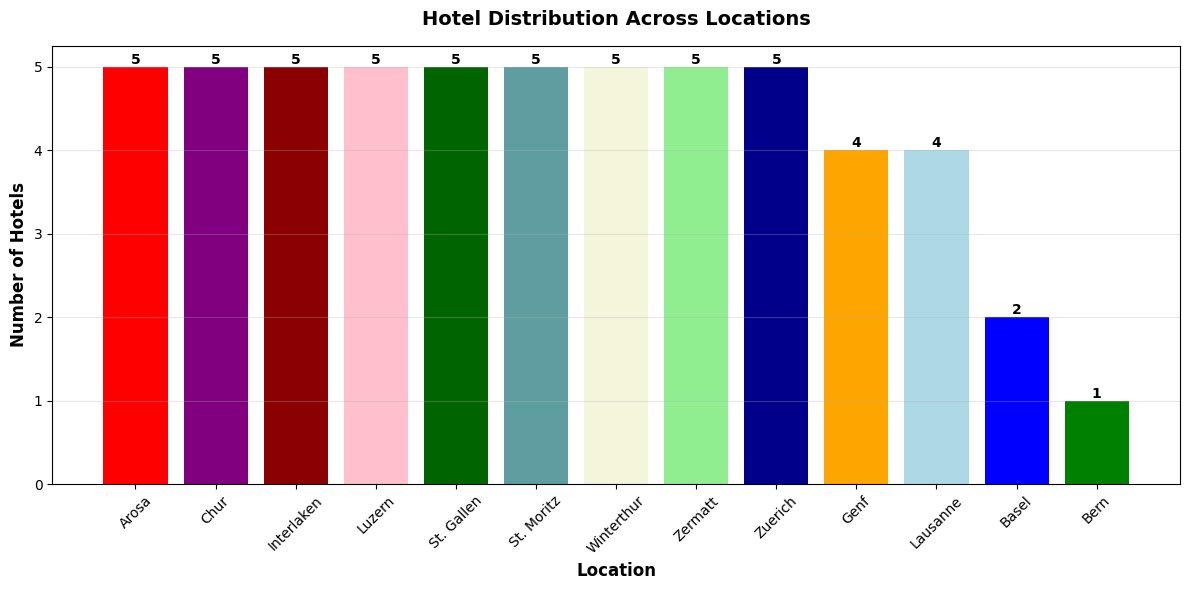


Hotels per location:
location
Arosa         5
Chur          5
Interlaken    5
Luzern        5
St. Gallen    5
St. Moritz    5
Winterthur    5
Zermatt       5
Zuerich       5
Genf          4
Lausanne      4
Basel         2
Bern          1


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

location_counts = hotel_summary['location'].value_counts()

plt.figure(figsize=(12, 6))
bars = plt.bar(location_counts.index, location_counts.values, 
               color=[location_colors.get(loc, 'gray') for loc in location_counts.index])
plt.xlabel('Location', fontsize=12, fontweight='bold')
plt.ylabel('Number of Hotels', fontsize=12, fontweight='bold')
plt.title('Hotel Distribution Across Locations', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nHotels per location:")
print(location_counts.to_string())

## Geographic Spread Analysis

In [42]:
location_stats = hotel_summary.groupby('location').agg({
    'latitude': ['mean', 'min', 'max'],
    'longitude': ['mean', 'min', 'max'],
    'avg_price': 'mean',
    'hotel_id': 'count'
}).round(4)

location_stats.columns = ['Lat_Mean', 'Lat_Min', 'Lat_Max', 'Lon_Mean', 'Lon_Min', 'Lon_Max', 'Avg_Price', 'Hotel_Count']
print("\nLocation Geographic Statistics:")
print(location_stats.to_string())


Location Geographic Statistics:
            Lat_Mean  Lat_Min  Lat_Max  Lon_Mean  Lon_Min  Lon_Max  Avg_Price  Hotel_Count
location                                                                                  
Arosa        47.3759  47.3665  47.3825    8.5386   8.5352   8.5444   281.4880            5
Basel        47.5438  47.5409  47.5468    7.5898   7.5843   7.5953   142.8150            2
Bern         46.9488  46.9488  46.9488    7.4463   7.4463   7.4463   210.9900            1
Chur         47.3759  47.3665  47.3825    8.5386   8.5352   8.5444   249.2160            5
Genf         46.2148  46.2076  46.2246    6.1410   6.1327   6.1470   307.7500            4
Interlaken   47.3759  47.3665  47.3825    8.5386   8.5352   8.5444   253.7480            5
Lausanne     46.2148  46.2076  46.2246    6.1410   6.1327   6.1470   302.8175            4
Luzern       47.3759  47.3665  47.3825    8.5386   8.5352   8.5444   228.1120            5
St. Gallen   47.3759  47.3665  47.3825    8.5386   8.5352